# 🌍 Global Food Prices, Inflation & Nutrition: An Exploratory Data Analysis

**Author:** *(your name here)*
**Last updated:** *(date)*

## Project Overview
Rising food prices don't hit every country the same way. This project explores how **food price shocks**,
**inflation**, and **malnutrition indicators** (stunting, wasting, undernourishment) are connected across
30 countries from 2015–2024, and how global commodity/food-price shocks (COVID-19, the Russia–Ukraine war,
regional droughts) line up with spikes in hunger.

## Workflow
This notebook follows the standard data analysis pipeline:

1. **Data Loading & Inspection** – load the datasets and understand their shape and structure
2. **Data Cleaning** – check for missing values, duplicates, and correct data types
3. **Exploratory Data Analysis (EDA)** – summary statistics and group comparisons
4. **Data Visualization** – charts that reveal patterns and relationships
5. **Insights & Conclusions** – what the data tells us, and ideas for further analysis

## Datasets Used
| File | What it contains |
|---|---|
| `food_price_vs_nutrition.csv` | **Main panel dataset** — country-year level: food/general inflation, GHI score, stunting/wasting/undernourishment, GDP per capita, etc. (2015–2024, 30 countries) |
| `fao_food_price_index.csv` | Global monthly/annual FAO Food Price Index (FFPI) since 2015 |
| `food_crises_events.csv` | Documented global food crisis events (e.g. COVID-19, Russia-Ukraine war) with dates |
| `global_hunger_index.csv` | Global Hunger Index (GHI) scores by country/year |
| `regional_summary.csv` | Pre-aggregated regional averages for inflation & nutrition indicators |



## 1. Setup: Import Libraries

We'll use:
- **pandas** loading and manipulating tabular data
- **numpy** numerical operations
- **matplotlib** & **seaborn** data visualization
- **matplotlib styles** to customize the visual elements of a plot
- **SciPy** for advanced mathematics and scientific computing

`sns.set_theme()` gives our charts a clean, consistent, presentation-ready look by default, so we don't
have to manually style every single plot.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import seaborn as sns
import scipy as sp

# Set a consistent, presentation-ready visual style for all charts in this notebook
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110          # sharper plots
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

# Show all columns when we print DataFrames (helpful for wide datasets)
pd.set_option("display.max_columns", None)

## 2. Data Loading & Inspection

**Why this step matters:** Before touching the data, we need to know what we're working with —
how many rows/columns, what types each column is, and whether anything looks broken. Skipping this
step is one of the most common beginner mistakes; it leads to bugs later that are much harder to trace.

> **Note on file paths:** This notebook was developed against files in `./`. When you
> clone this from GitHub, update `DATA_DIR`
> below as `DATA_DIR = "data/"`.


In [2]:
# Change this if you move the CSVs (e.g. to a "data/" folder for GitHub)
DATA_DIR = "./"

# Main panel dataset: country-year food price / inflation / nutrition indicators
df = pd.read_csv(DATA_DIR + "food_price_vs_nutrition.csv")

# Supplementary datasets for extra context
fao = pd.read_csv(DATA_DIR + "fao_food_price_index.csv")       # Global monthly/annual food price index
crises = pd.read_csv(DATA_DIR + "food_crises_events.csv")      # Documented global food crisis events
regional = pd.read_csv(DATA_DIR + "regional_summary.csv")      # Pre-aggregated regional averages

print("Main dataset shape:", df.shape)
df.head()

Main dataset shape: (300, 20)


,country,iso3,region,income_group,year,fao_food_price_index,general_inflation_pct,food_inflation_pct,food_inflation_premium_pp,stunting_pct,wasting_pct,underweight_pct,overweight_pct,undernourishment_pct,food_insecurity_pct,ghi_score,ghi_category,population_millions,gdp_per_capita_usd,food_import_dependency_pct
0,Afghanistan,AFG,South Asia,Low income,2015,93.0,-0.7,-3.1,-2.4,40.9,9.5,25.0,5.4,26.8,52.4,35.4,Alarming,42.2,363,42.5
1,Afghanistan,AFG,South Asia,Low income,2016,91.9,4.4,4.9,0.5,40.5,9.3,24.6,5.3,27.5,53.1,34.8,Serious,42.2,363,42.5
2,Afghanistan,AFG,South Asia,Low income,2017,98.0,5.0,8.3,3.3,40.0,9.1,24.2,5.3,28.2,54.0,34.3,Serious,42.2,363,42.5
3,Afghanistan,AFG,South Asia,Low income,2018,95.9,0.6,0.9,0.3,39.5,8.9,23.8,5.2,29.8,55.6,34.0,Serious,42.2,363,42.5
4,Afghanistan,AFG,South Asia,Low income,2019,95.1,2.3,3.7,1.4,39.0,8.7,23.4,5.2,30.5,56.2,33.8,Serious,42.2,363,42.5


`.shape` tells us (rows, columns). `.head()` previews the first 5 rows so we can eyeball the data.
Next, `.info()` shows column data types and non-null counts in one go which is a fast way to spot missing values
or a column that loaded as the wrong type (e.g. numbers stored as text).

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     300 non-null    str    
 1   iso3                        300 non-null    str    
 2   region                      300 non-null    str    
 3   income_group                300 non-null    str    
 4   year                        300 non-null    int64  
 5   fao_food_price_index        300 non-null    float64
 6   general_inflation_pct       300 non-null    float64
 7   food_inflation_pct          300 non-null    float64
 8   food_inflation_premium_pp   300 non-null    float64
 9   stunting_pct                300 non-null    float64
 10  wasting_pct                 300 non-null    float64
 11  underweight_pct             300 non-null    float64
 12  overweight_pct              300 non-null    float64
 13  undernourishment_pct        300 non-null    fl

In [4]:
# Quick statistical summary of all numeric columns:
# count, mean, std, min/max, and quartiles (25/50/75%)
df.describe()


,year,fao_food_price_index,general_inflation_pct,food_inflation_pct,food_inflation_premium_pp,stunting_pct,wasting_pct,underweight_pct,overweight_pct,undernourishment_pct,food_insecurity_pct,ghi_score,population_millions,gdp_per_capita_usd,food_import_dependency_pct
count,300.00000,300.00000,300.000000,300.000000,300.000000,300.00000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2019.50000,108.42000,12.246000,15.407000,3.161000,24.77500,6.603667,15.342667,5.834667,15.711333,31.140667,20.984333,190.936667,9219.633333,20.826667
std,2.87708,17.17933,26.531516,31.989377,6.600206,14.56491,5.134149,11.393129,4.039967,13.792732,22.535990,12.267947,342.864245,18062.902143,17.654486
min,2015.00000,91.90000,-6.600000,-12.300000,-9.900000,0.60000,0.100000,0.200000,1.200000,2.500000,2.500000,4.500000,11.700000,363.000000,4.100000
25%,2017.00000,95.10000,3.400000,3.675000,0.275000,10.72500,1.800000,3.775000,3.075000,4.500000,11.425000,7.500000,34.400000,1027.000000,8.300000
50%,2019.50000,98.05000,5.750000,7.750000,1.700000,27.10000,6.150000,15.700000,4.300000,10.500000,27.500000,20.850000,85.150000,2586.500000,14.950000
75%,2022.00000,122.20000,11.400000,14.800000,4.200000,37.42500,9.825000,24.200000,7.600000,24.575000,49.900000,31.225000,174.700000,6191.000000,25.800000
max,2024.00000,143.70000,359.100000,412.600000,53.500000,47.80000,21.000000,39.900000,16.700000,53.500000,83.200000,47.300000,1441.700000,80412.000000,85.300000


In [5]:
# How many unique countries, and which years does the data span?
print("Countries:", df['country'].nunique())
print("Years:", df['year'].min(), "-", df['year'].max())
print("Regions:", df['region'].unique())


Countries: 30
Years: 2015 - 2024
Regions: <StringArray>
[            'South Asia',          'Latin America',     'Sub-Saharan Africa',
    'East Asia & Pacific', 'Middle East & N.Africa',            'High Income']
Length: 6, dtype: str


## 3. Data Cleaning

**This step matters:** Real-world data almost always has issues like missing values, duplicate rows,
or inconsistent types. Even when a dataset *looks* clean, it's good practice to verify that
programmatically rather than assume.

Here we check for:
1. Missing values (`.isna().sum()`)
2. Duplicate rows (`.duplicated()`)
3. Correct data types (e.g. `year` should be an integer, not a string)


In [6]:
# 1. Missing values per column
missing = df.isna().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found! ✅")

Missing values per column:
No missing values found! ✅


In [7]:
# 2. Duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [8]:
# 3. Data types — confirm 'year' is numeric and category-like columns are strings
print(df.dtypes)

country                           str
iso3                              str
region                            str
income_group                      str
year                            int64
fao_food_price_index          float64
general_inflation_pct         float64
food_inflation_pct            float64
food_inflation_premium_pp     float64
stunting_pct                  float64
wasting_pct                   float64
underweight_pct               float64
overweight_pct                float64
undernourishment_pct          float64
food_insecurity_pct           float64
ghi_score                     float64
ghi_category                      str
population_millions           float64
gdp_per_capita_usd              int64
food_import_dependency_pct    float64
dtype: object


This dataset came pre-cleaned (no missing values or duplicates), which is common for
curated project datasets but rare "in the wild." Even so, it's worth adding one feature that will make
our later analysis easier: a **decade-agnostic period flag** marking whether a row falls during a known
global food-price shock (from `food_crises_events.csv`), so we can compare "shock years" vs "normal years."


In [9]:
# Feature engineering: flag whether each row's year falls within a global food crisis window
# (using the food_crises_events dataset's start/end years)
crisis_years = set()
for _, row in crises.iterrows():
    crisis_years.update(range(int(row['year_start']), int(row['year_end']) + 1))

df['is_crisis_year'] = df['year'].isin(crisis_years)

print(f"Crisis years identified: {sorted(crisis_years)}")
df[['country', 'year', 'is_crisis_year']].head()


Crisis years identified: [2010, 2011, 2012, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


,country,year,is_crisis_year
0,Afghanistan,2015,True
1,Afghanistan,2016,True
2,Afghanistan,2017,True
3,Afghanistan,2018,True
4,Afghanistan,2019,True


## 4. Exploratory Data Analysis (EDA)

Now that the data is clean, let's start asking questions of it. We'll look at:
- How key indicators differ by **income group**
- How **regions** compare on hunger/nutrition
- Which variables are **correlated** with each other


In [10]:
# Average undernourishment and food insecurity by income group
income_summary = (
    df.groupby('income_group')[['undernourishment_pct', 'food_insecurity_pct', 'ghi_score']]
    .mean()
    .round(1)
    .sort_values('ghi_score', ascending=False)
)
income_summary


,undernourishment_pct,food_insecurity_pct,ghi_score
income_group,,,
Low income,30.8,56.3,33.9
Lower middle income,11.3,26.2,20.1
Upper middle income,6.1,14.4,10.7
High income,2.5,2.9,5.0


`.groupby('income_group')` splits the DataFrame into groups by income level, then `.mean()` computes
the average of our chosen columns **within each group**. This is one of the most useful pandas patterns
"split, apply, combine" and you'll use it constantly in real analysis work.

**What we see:** Low-income countries show dramatically higher undernourishment, food insecurity, and
GHI (Global Hunger Index) scores than higher-income groups — confirming a strong income–hunger relationship.


In [11]:
# Regional comparison: average GHI score and food inflation by region (latest year, 2024)
latest = df[df['year'] == df['year'].max()]

regional_latest = (
    latest.groupby('region')[['ghi_score', 'food_inflation_pct', 'undernourishment_pct']]
    .mean()
    .round(1)
    .sort_values('ghi_score', ascending=False)
)
regional_latest


,ghi_score,food_inflation_pct,undernourishment_pct
region,,,
Sub-Saharan Africa,28.8,27.9,25.0
South Asia,22.4,4.1,14.7
Latin America,17.0,11.5,18.7
Middle East & N.Africa,15.5,33.1,14.6
East Asia & Pacific,13.2,5.0,7.3
High Income,5.0,2.2,2.5


In [12]:
# Correlation matrix: which numeric variables move together?
numeric_cols = [
    'fao_food_price_index', 'general_inflation_pct', 'food_inflation_pct',
    'stunting_pct', 'wasting_pct', 'undernourishment_pct', 'food_insecurity_pct',
    'ghi_score', 'gdp_per_capita_usd', 'food_import_dependency_pct'
]
corr = df[numeric_cols].corr()
corr.round(2)


,fao_food_price_index,general_inflation_pct,food_inflation_pct,stunting_pct,wasting_pct,undernourishment_pct,food_insecurity_pct,ghi_score,gdp_per_capita_usd,food_import_dependency_pct
fao_food_price_index,1.00,0.17,0.18,-0.09,-0.09,0.05,0.05,-0.05,0.00,0.00
general_inflation_pct,0.17,1.00,0.99,0.06,0.15,0.19,0.21,0.14,-0.13,0.09
food_inflation_pct,0.18,0.99,1.00,0.06,0.16,0.20,0.22,0.15,-0.14,0.11
stunting_pct,-0.09,0.06,0.06,1.00,0.65,0.63,0.77,0.87,-0.63,0.30
wasting_pct,-0.09,0.15,0.16,0.65,1.00,0.39,0.50,0.68,-0.49,0.24
undernourishment_pct,0.05,0.19,0.20,0.63,0.39,1.00,0.97,0.88,-0.42,0.67
food_insecurity_pct,0.05,0.21,0.22,0.77,0.50,0.97,1.00,0.94,-0.52,0.64
ghi_score,-0.05,0.14,0.15,0.87,0.68,0.88,0.94,1.00,-0.55,0.52
gdp_per_capita_usd,0.00,-0.13,-0.14,-0.63,-0.49,-0.42,-0.52,-0.55,1.00,-0.15
food_import_dependency_pct,0.00,0.09,0.11,0.30,0.24,0.67,0.64,0.52,-0.15,1.00


`.corr()` computes the **Pearson correlation coefficient** between every pair of numeric columns,
ranging from -1 (perfectly inverse) to +1 (perfectly aligned). We'll visualize this as a heatmap next
much easier to read than a table of numbers.

## 5. Data Visualization

Now let's turn these numbers into charts. Each plot below is built to answer a specific question.


### 5.1 Global Food Price Index Over Time, With Crisis Events Marked

**Question:** How has the global FAO Food Price Index moved since 2015, and do spikes line up with
known crises (COVID-19, the Russia–Ukraine war, etc.)?


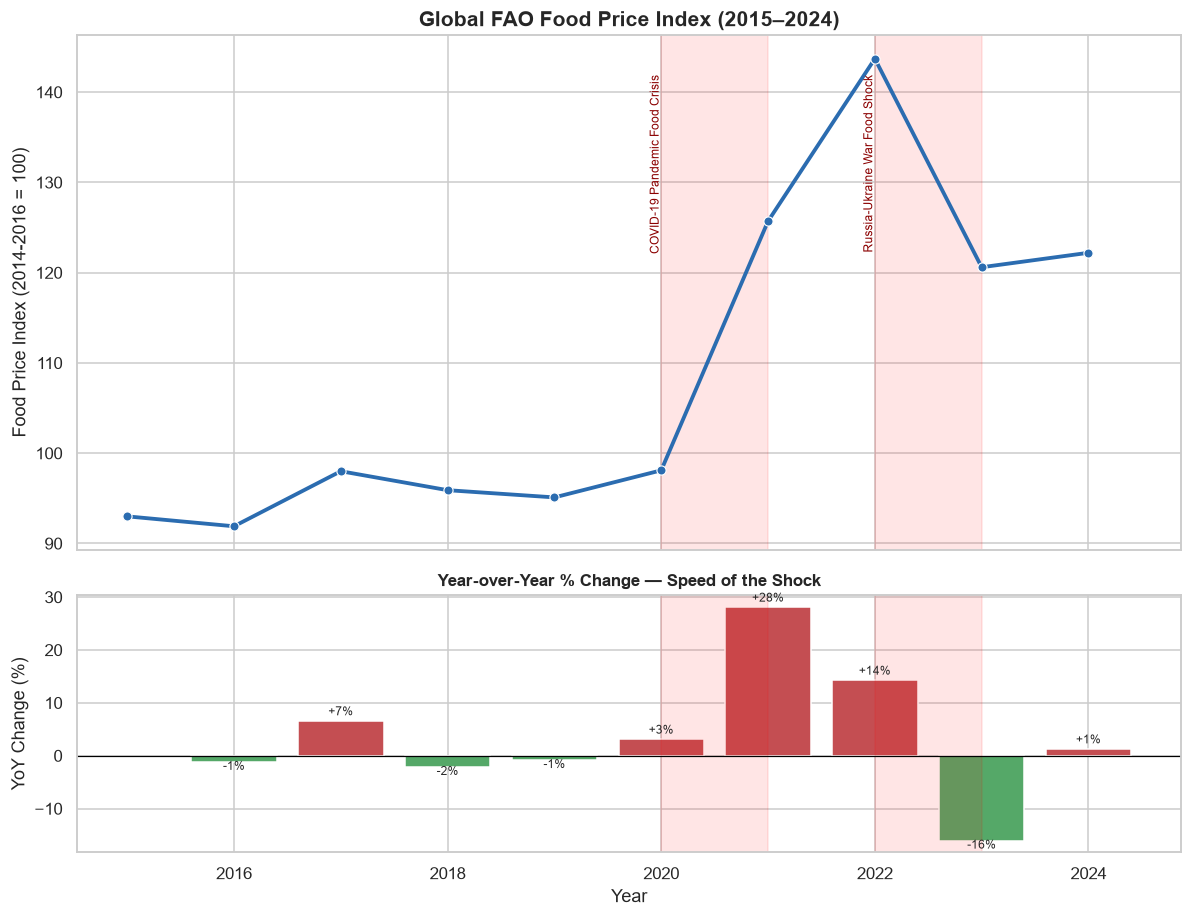

In [13]:
fao_annual = fao[fao['frequency'] == 'annual'].sort_values('year')
global_crises = crises[crises['regions_affected'].str.contains('global', case=False, na=False) |
                        crises['crisis_name'].str.contains('COVID|Russia', case=False, na=False)]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8.5), sharex=True,
                                 gridspec_kw={'height_ratios': [2, 1]})
sns.lineplot(data=fao_annual, x='year', y='food_price_index', marker='o', linewidth=2.5, ax=ax1, color='#2b6cb0')
for _, c in global_crises.iterrows():
    ax1.axvspan(c['year_start'], c['year_end'], color='red', alpha=0.1)
    ax1.text(c['year_start'], ax1.get_ylim()[1]*0.97, c['crisis_name'].split('(')[0],
              rotation=90, va='top', ha='right', fontsize=8, color='darkred')
ax1.set_title("Global FAO Food Price Index (2015–2024)")
ax1.set_ylabel("Food Price Index (2014-2016 = 100)")
ax1.set_xlabel("")  # shared x-axis, so no need to label it twice

# --- Bottom panel: year-over-year % change ---
fao_annual['yoy_pct_change'] = fao_annual['food_price_index'].pct_change() * 100

# Bar colors flag direction directly: red = accelerating prices, green = easing prices
colors = ['#c44e52' if v >= 0 else '#55a868' for v in fao_annual['yoy_pct_change'].fillna(0)]
ax2.bar(fao_annual['year'], fao_annual['yoy_pct_change'], color=colors)
ax2.axhline(0, color='black', linewidth=0.8)
for _, c in global_crises.iterrows():
    ax2.axvspan(c['year_start'], c['year_end'], color='red', alpha=0.1)
for x, y in zip(fao_annual['year'], fao_annual['yoy_pct_change']):
    if pd.notna(y):
        ax2.text(x, y + (1 if y >= 0 else -1.5), f"{y:+.0f}%", ha='center', fontsize=8)

ax2.set_ylabel("YoY Change (%)")
ax2.set_xlabel("Year")
ax2.set_title("Year-over-Year % Change — Speed of the Shock", fontsize=11)

plt.tight_layout()
plt.savefig('01_ffpi_trend.png', bbox_inches='tight')
plt.show()

**Interpretation:** The index jumps sharply after 2020, peaking around 2022 squarely aligned
with the COVID-19 supply chain disruptions and the Russia–Ukraine war (both major global grain/fertilizer
exporters). Prices ease somewhat in 2023–2024 but remain well above pre-2020 levels.


### 5.2 Food Inflation vs. Child Stunting

**Question:** Do countries with higher food inflation tend to have worse child stunting outcomes?


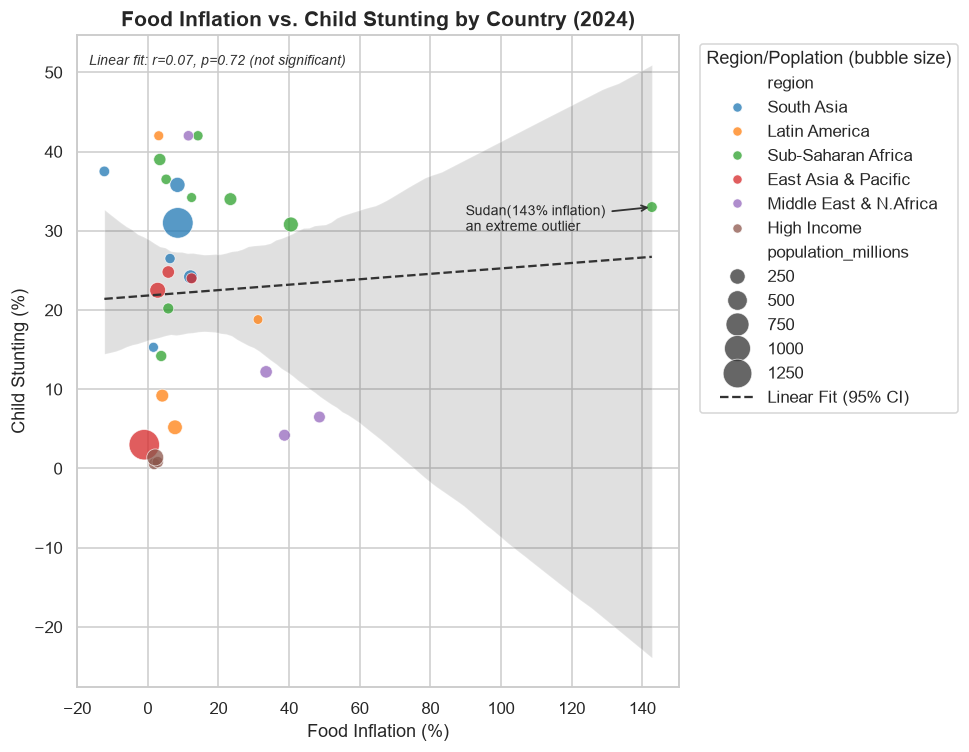

In [14]:
from scipy import stats
fig, ax = plt.subplots(figsize=(9, 7))
sns.regplot(
    data = latest, x = 'food_inflation_pct', y='stunting_pct',
    scatter=False, ci=95, ax=ax,
    line_kws={'color':'#333333', 'linewidth':1.5, 'linestyle':'--'}
)
sns.scatterplot(
    data = latest, x = 'food_inflation_pct', y='stunting_pct',
    hue='region', size='population_millions', sizes=(40,400),
    alpha=0.75, ax=ax, palette='tab10'
)
sudan=latest[latest['country']=='Sudan'].iloc[0]
ax.annotate(
    f"Sudan({sudan['food_inflation_pct']:.0f}% inflation)\nan extreme outlier",
    xy=(sudan['food_inflation_pct'], sudan['stunting_pct']),
    xytext=(90,30),
    arrowprops=dict(arrowstyle='->', color='#333333', lw=1.2),
    fontsize=9, ha='left'
)
slope, intercept, r, pval, se = stats.linregress(latest['food_inflation_pct'], latest['stunting_pct'])
ax.text(0.02,0.97,f"Linear fit: r={r:.2f}, p={pval:.2f} (not significant)",
        transform=ax.transAxes, fontsize=9, va='top', style='italic', color='#333333')
ax.set_title("Food Inflation vs. Child Stunting by Country (2024)")
ax.set_xlabel("Food Inflation (%)")
ax.set_ylabel("Child Stunting (%)")
handles, labels = ax.get_legend_handles_labels()
# Remove the default legend and create a custom one
fit_line=mlines.Line2D([], [], color='#333333', linestyle='--', linewidth=1.5, label='Linear Fit (95% CI)')
ax.legend(handles=handles+[fit_line], labels=labels+['Linear Fit (95% CI)'],
          bbox_to_anchor=(1.02, 1), loc='upper left', title='Region/Poplation (bubble size)')
plt.tight_layout()
plt.savefig('02_food_inflation_vs_stunting.png', bbox_inches='tight')
plt.show()

**Interpretation:** Bubble size encodes population, and color encodes region. Sub-Saharan African
and South Asian countries cluster toward the upper-right higher food inflation *and* higher stunting
while high-income countries sit near the bottom-left. This is suggestive, not conclusive: correlation
isn't causation, and structural poverty likely drives both variables.


### 5.3 Average GHI Score by Region

**Question:** Which regions face the most severe hunger, on average?


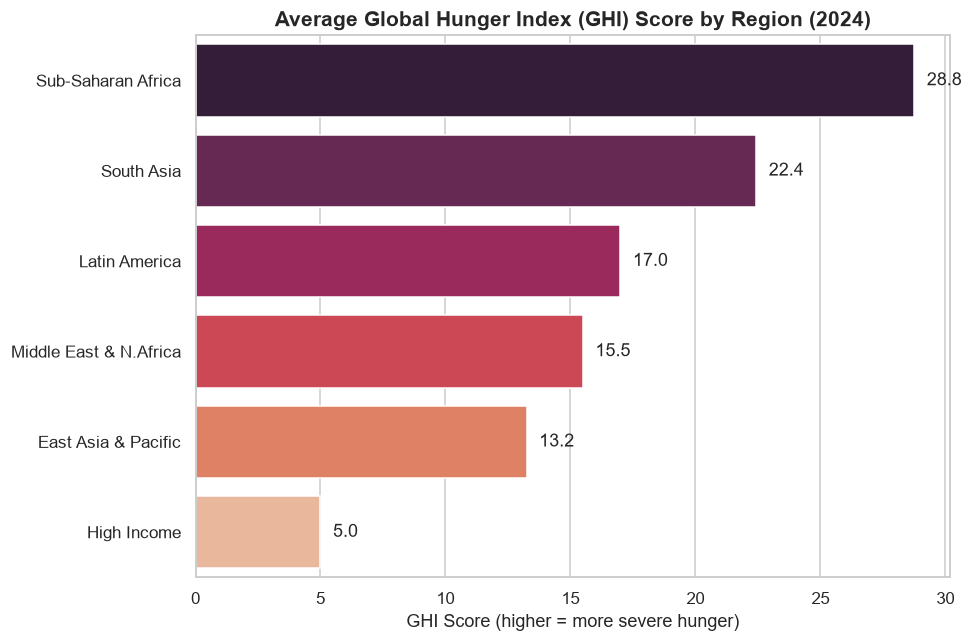

In [15]:
region_ghi = latest.groupby('region')['ghi_score'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=region_ghi.values, y=region_ghi.index, hue=region_ghi.index,
            palette='rocket', legend=False, ax=ax)
ax.set_title("Average Global Hunger Index (GHI) Score by Region (2024)")
ax.set_xlabel("GHI Score (higher = more severe hunger)")
ax.set_ylabel("")
for i, v in enumerate(region_ghi.values):
    ax.text(v + 0.5, i, f"{v:.1f}", va='center')
plt.tight_layout()
plt.savefig('03_ghi_by_region.png', bbox_inches='tight')
plt.show()


**Interpretation:** Sub-Saharan Africa and South Asia show the highest average GHI scores
(worse hunger), consistent with global hunger reporting. High-income regions sit near the bottom of
the scale, close to 0.


### 5.4 Correlation Heatmap

**Question:** Which economic and nutrition variables move together most strongly?


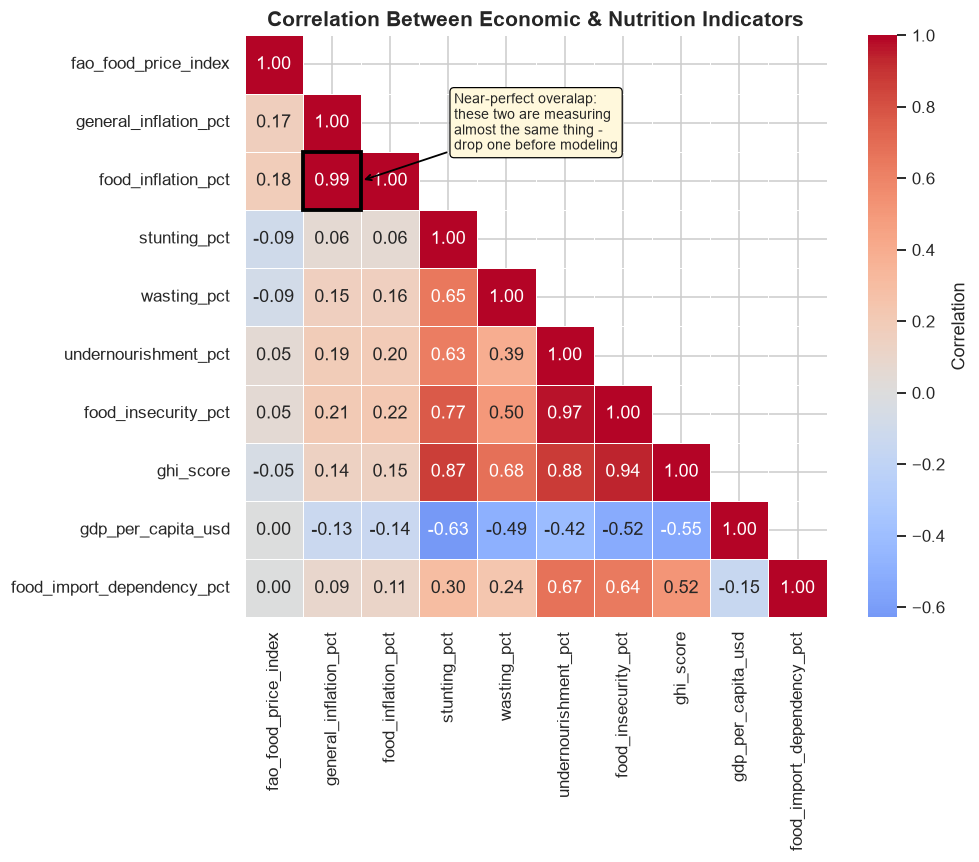

In [16]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'}, ax=ax)
row_idx=numeric_cols.index('food_inflation_pct')
col_idx=numeric_cols.index('general_inflation_pct')
ax.add_patch(patches.Rectangle((col_idx, row_idx),1,1, fill=False, edgecolor='black', lw=2.5))
ax.annotate(
    "Near-perfect overalap:\nthese two are measuring\nalmost the same thing -\ndrop one before modeling",
    xy=(col_idx+1, row_idx+0.5), xycoords='data',
    xytext=(col_idx+2.6, row_idx-0.5), textcoords='data',
    arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
    fontsize=9, va='center', ha='left',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff8dc', ec='black', lw=0.8)
)
ax.set_title("Correlation Between Economic & Nutrition Indicators")
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Interpretation:** `gdp_per_capita_usd` is strongly *negatively* correlated with stunting,
undernourishment, and GHI score wealthier countries see much better nutrition outcomes. Meanwhile,
`food_import_dependency_pct` correlates positively with several hunger indicators, hinting that
countries reliant on food imports are more exposed to global price shocks.

general_inflation_pct and food_inflation_pct correlate at r=0.99 likely because food inflation is a dominant component of headline inflation.

### 5.5 Top 10 Most Food-Insecure Countries (2024)

**Question:** Which specific countries are facing the most severe food insecurity right now?


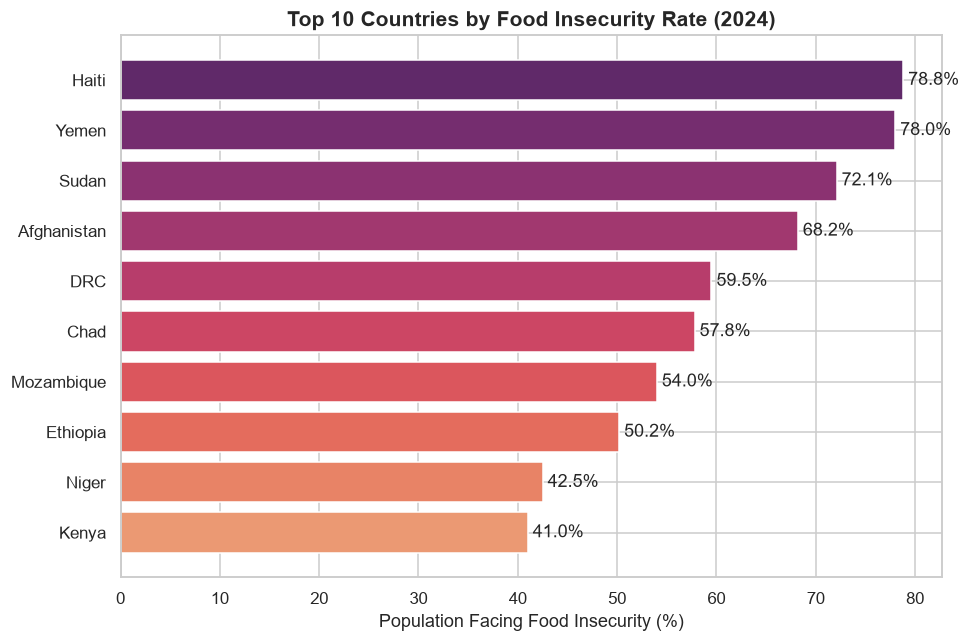

In [17]:
top10 = latest.nlargest(10, 'food_insecurity_pct').sort_values('food_insecurity_pct')

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top10['country'], top10['food_insecurity_pct'], color=sns.color_palette('flare', 10))
ax.set_title("Top 10 Countries by Food Insecurity Rate (2024)")
ax.set_xlabel("Population Facing Food Insecurity (%)")
for bar, val in zip(bars, top10['food_insecurity_pct']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va='center')
plt.tight_layout()
plt.savefig('05_top10_food_insecurity.png', bbox_inches='tight')
plt.show()


**Interpretation:** This chart puts a human face on the aggregate statistics these are the
specific countries where the largest share of the population struggles to reliably access food in 2024.


### 5.6 Undernourishment Distribution by Income Group

**Question:** How much *spread* is there in undernourishment within each income group is it
consistent, or do some income groups have a few extreme outliers?


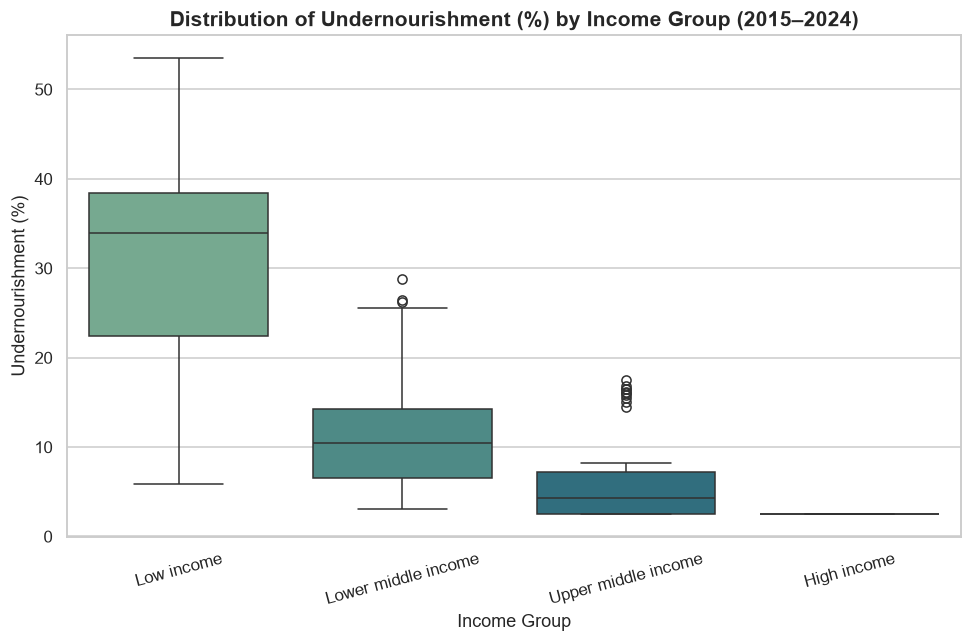

In [18]:
order = df.groupby('income_group')['undernourishment_pct'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=df, x='income_group', y='undernourishment_pct', order=order,
            hue='income_group', palette='crest', legend=False, ax=ax)
ax.set_title("Distribution of Undernourishment (%) by Income Group (2015–2024)")
ax.set_xlabel("Income Group")
ax.set_ylabel("Undernourishment (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('06_undernourishment_boxplot.png', bbox_inches='tight')
plt.show()


**Interpretation:** A boxplot shows the median (middle line), interquartile range (the box), and
outliers (individual points beyond the whiskers). Low-income countries not only have a higher median
undernourishment rate but also much wider variation — some countries within that group are doing
relatively better or dramatically worse than others.


### 5.7 Food Import Dependency vs GDP per capita

**Question:** Is there a clear indiaction for a shock vulnerability through the import dependency and GDP?

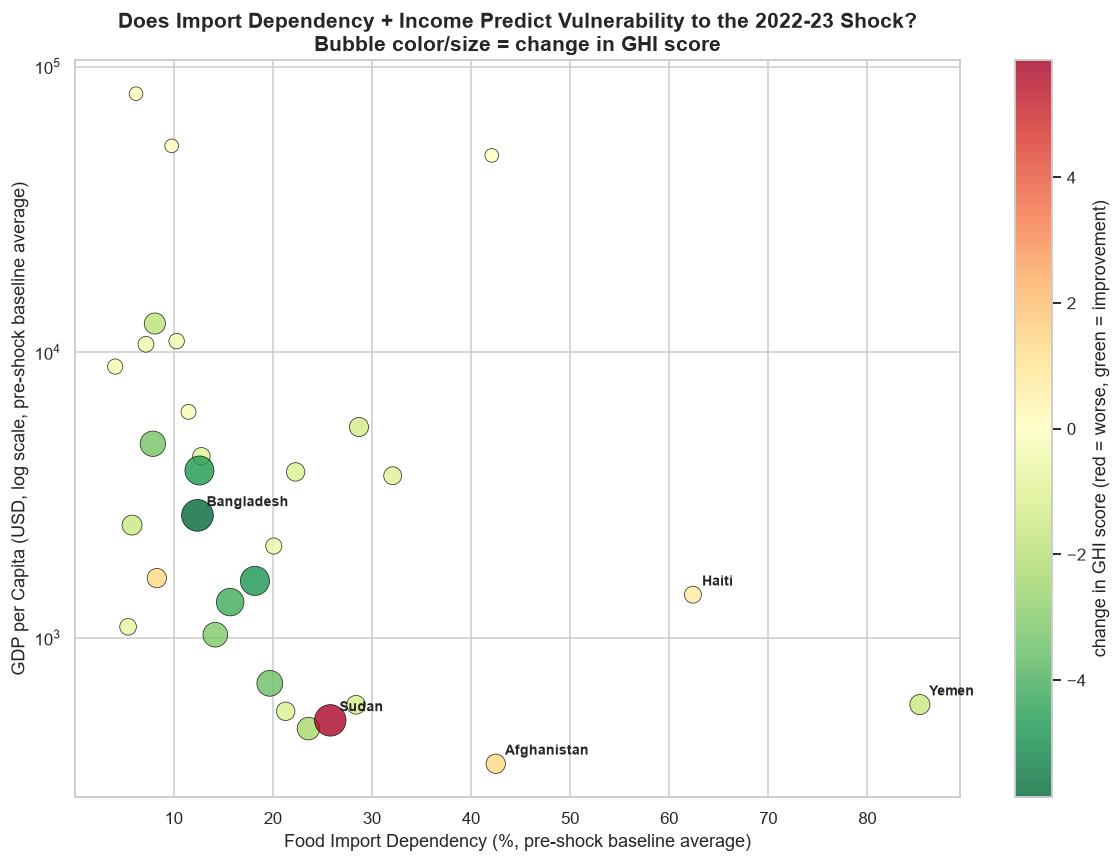

                            food_import_dependency_pct  gdp_per_capita_usd  \
food_import_dependency_pct                       1.000              -0.146   
gdp_per_capita_usd                              -0.146               1.000   
ghi_change                                       0.175               0.177   

                            ghi_change  
food_import_dependency_pct       0.175  
gdp_per_capita_usd               0.177  
ghi_change                       1.000  


In [19]:
data = df.copy()
conditions = [data['year']<2022, (data['year']>=2022) & (data['year']<=2023), data['year']>2023]
data['period']=np.select(conditions, ['before', 'during','after'],default='')
baseline = data[data['period']=='before'].groupby('country')[['food_import_dependency_pct','gdp_per_capita_usd']].mean()
ghi_before=data[data['period']=='before'].groupby('country')['ghi_score'].mean()
ghi_during=data[data['period']=='during'].groupby('country')['ghi_score'].mean()
ghi_change=(ghi_during-ghi_before).rename('ghi_change')
combined=baseline.join(ghi_change).reset_index()
fig, ax=plt.subplots(figsize=(11,8))
vmax=combined['ghi_change'].abs().max()
norm=mcolors.TwoSlopeNorm(vmin=-vmax,vcenter=0,vmax=vmax)
scatter=ax.scatter(
        combined['food_import_dependency_pct'],combined['gdp_per_capita_usd'],
        c=combined['ghi_change'], cmap='RdYlGn_r',norm=norm,
        s=combined['ghi_change'].abs()*60+80, #bubble size also encodes magnitude of the change
        alpha=0.8, edgecolor='black', linewidth=0.5
)
ax.set_yscale('log')
ax.set_xlabel("Food Import Dependency (%, pre-shock baseline average)")
ax.set_ylabel("GDP per Capita (USD, log scale, pre-shock baseline average)")
ax.set_title("Does Import Dependency + Income Predict Vulnerability to the 2022-23 Shock?\nBubble color/size = change in GHI score")
cbar=plt.colorbar(scatter, ax=ax)
cbar.set_label("change in GHI score (red = worse, green = improvement)")
highlight = ['Sudan','Yemen','Bangladesh','Afghanistan','Haiti']
for _, row in combined[combined['country'].isin(highlight)].iterrows():
        ax.annotate(row['country'], (row['food_import_dependency_pct'], row['gdp_per_capita_usd']),
                textcoords="offset points", xytext=(6, 6), fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig('08_import_gdp_vulnerability.png', bbox_inches='tight')
plt.show()
print(combined[['food_import_dependency_pct','gdp_per_capita_usd', 'ghi_change']].corr().round(3))

Contrary to the simple hypothesis that high import dependency and low income jointly predict shock vulnerability, this chart shows only a weak relationship between either variable and the change in GHI (r ≈ 0.18 for both). The countries with the worst outcomes like Sudan, Afghanistan, Haiti share something the chart's two axes don't capture directly: active conflict or acute state fragility. Meanwhile Yemen, despite extreme import dependency, saw no deterioration, likely because it was already at a severely elevated baseline with limited room to worsen further (the same "already in crisis" effect seen in the food-inflation ranking chart). This suggests that conflict and governance capacity, not income or trade exposure alone, are the dominant drivers of hunger-outcome vulnerability to global shocks in this dataset. A more nuanced and arguably more useful finding than a straightforward confirmation would have been.

## 6. Insights & Conclusions

Bringing it all together, this analysis suggests:

1. **Global food prices spiked sharply from 2020–2022**, coinciding with COVID-19 supply disruptions
   and the Russia–Ukraine war, and remain elevated relative to 2015–2019 levels.
2. **Income is the strongest single predictor** of nutrition outcomes in this dataset GDP per capita
   is strongly negatively correlated with stunting, undernourishment, and GHI score.
3. **Sub-Saharan Africa and South Asia** carry the heaviest hunger burden, both in regional averages and
   in the countries appearing on the "most food-insecure" list.
4. **Food import dependency** is associated with worse hunger outcomes, suggesting countries reliant on
   imports are more exposed to the global price shocks charted in Section 5.1.
5. Even within the same income group, outcomes vary widely (Section 5.6) income explains a lot, but
   not everything. Conflict, governance, and climate shocks (visible in `food_crises_events.csv`) likely
   explain much of the remaining variation.
6. Pre shock and post shock Food import dependency and GDP per capita is a very weak indicator of hunger outcome vulnerability  in global shock scenarios

### Limitations
- The panel only covers 30 countries and 10 years not a random global sample.
- Correlation shown here does **not** imply causation; many of these variables are entangled with deeper
  structural factors (governance, conflict, climate).

## 7. Suggested Next Steps
- Merge in `food_crises_events.csv` regions more precisely and compare **before/during/after crisis**
  nutrition metrics for affected countries specifically.
- Build a simple regression model predicting `ghi_score` from economic and price variables.
- Explore `crop_yields.csv` and `commodity_prices.csv` to connect production-side shocks (e.g. wheat
  yields) to the price and nutrition trends seen here.
